# HW Tool

### Нафикова Лиана

## 1. `shap.plots.beeswarm` нормального человека (6 баллов)

Как вы могли видеть, у встроенного beeswarm plot`а есть несколько недостатков:
- нет информации о том, какие именно значения категориальных признаков в какую сторону толкают предсказания модели
- иногда серые точки (пропущенные значения) прячутся за точками другого цвета -> их не видно (см. rooms_num на графике с семинара)
- иногда раскраска бывает некорректной (потому что она раскрашивает по абсолютным значениям)

Вам предлагается реализовать свою версию shap.plots.beeswarm, которая исправляет эти недостатки.


Итак, требуется написать функцию, которая принимает на вход shap_values и все необходимое и строит по этим данным beeswarm plot
    без вышеперечисленных недостатков, а именно:
- теперь все уникальные значения кат. фич становятся как бы отдельными фичами, по ним видны shap_values (см. пример)
    - чтобы не захламлять ваш график редковстречающимися категориями, принимайте на вход параметр, чтобы контролировать это
    - такие фичи должны быть покрашены в особый цвет, чтобы отличаться от числовых
- точки, отвечающие за наны, должны быть хорошо видны на фоне остальных и не перекрывать их
- раскраска должна адекватно красить ваши точки
    - можно выкидывать выбросы перед покраской
    - можно логарифмировать значения
    - можно красить по квантилям, а не по абсолютным значениям
    - лучше всего красятся равномерное и нормальное распределение

**Обязательно:**
- docstring
- комменты к непонятным кускам кода - что там происходит
- принимайте на вход кол-во фич, которые вы отображаете на графике
- принимайте на вход размер фигуры
- нарисуйте вертикальную линию, обозначающую 0
- сортируйте признаки по среднему модулю shap_values
- используйте stripplot (или аналоги) с jitter`ом, а не swarmplot
- принимайте на вход кол-во точек которое будете отрисовывать (500-3000 = норм)
    - если для какого-то значения кат фичи точек меньше, чем вы задали, рисуйте сколько есть

**!**
Если на вход подана слишком большая выборка, вы можете под капотом сэмплить из нее какое-то адекватное кол-во точек и отрисовывать их.
Однако, раскраску и контроль за отрисовкой категорий лучше базировать на всей выборке, поданной на вход.


Ниже приведен пример. Не меняйте код, предшествующий примеру. Вы не обязаны повторять пример точь-в-точь, это ориентир. Не удаляйте пример.

Удачи!

In [1]:
import numpy as np, pandas as pd
import lightgbm as lgb

%load_ext autoreload
%autoreload 2


df = pd.read_parquet('train_sber.parquet')
features = df.columns.drop(['timestamp', 'result_price', 'result_price_bin'])

model = lgb.Booster(model_file='model.lgb')
shap_values = model.predict(df[features], pred_contrib=True)

'''
Учтите, что если вы считаете shap_values через LightGBM,
    shap_values - np.array of shape (N, F + 1), где последний столбец - константа = среднее предсказание для всех объектов
'''
print('features shape:', features.shape, 'shap_values shape:', shap_values.shape)
df.head(3)

[LightGBM] [Warning] Ignoring unrecognized parameter 'bagging_by_query' found in model string.
features shape: (36,) shap_values shape: (27232, 37)


,district_area,road_distance_1,road_distance_2,year_of_construction,bulvar_ring_km,bus_station_distance,cafe_count,fitness_center_distance,floor,district_population,...,public_transport_station_distance,sadovoe_km,base_school_distance,sport_count,state,district_name,timestamp,malls_count,railway_station_distance,result_price_bin
0,6407578.100,1.422391,3.830951,NaN,13.675657,24.292406,152,0.485841,4.0,86206,...,3.299822,13.100618,0.177975,52,NaN,Bibirevo,2011-08-20,52,14.231961,False
1,9589336.912,2.887377,3.103996,NaN,8.132640,5.706113,177,0.668364,3.0,76284,...,0.783160,6.444333,0.273345,66,NaN,Nagatinskij Zaton,2011-08-23,40,9.242586,False
2,4808269.831,0.647250,2.927487,NaN,8.054252,6.710302,122,0.733101,2.0,101982,...,3.945073,6.963403,0.158072,67,NaN,Tekstil'shhiki,2011-08-27,35,9.540544,False


In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


def my_beeswarm(shap_values, df, features, min_cat_objects=1000, max_display=15, plot_size=(9, 6), sample_size=1000):
    """
    Строит beeswarm-график для визуализации SHAP-значений с поддержкой категориальных признаков.

    Функция преобразует категориальные признаки в набор бинарных признаков (по одной категории на признак),
    объединяет их с числовыми признаками и визуализирует в виде beeswarm-графика, где:
    - По оси Y - признаки, отсортированные по важности (средний абсолютный SHAP)
    - По оси X - SHAP-значения (влияние на модель)
    - Цвет точек для числовых признаков показывает значение признака (нормализованное)
    - Категориальные признаки отображаются бежевым цветом
    - Пропущенные значения отображаются черным цветом

    Параметры:
    ----------
    shap_values : numpy.ndarray или объект shap.Explanation
        Матрица SHAP-значений (объекты x признаки)
    df : pandas.DataFrame
        Датафрейм с исходными признаками (должен соответствовать shap_values)
    features : list
        Список названий признаков (должен соответствовать столбцам df и shap_values)
    min_cat_objects : int, optional
        Минимальное количество объектов в категории для её отображения (по умолчанию 1000)
    max_display : int, optional
        Максимальное количество признаков для отображения (по умолчанию 15)
    plot_size : tuple, optional
        Размер графика в дюймах (ширина, высота) (по умолчанию (9, 6))
    sample_size : int, optional
        Количество объектов для отображения по каждому признаку (по умолчанию 1000)

    Возвращает:
    -----------
    None
        Функция только отображает график, не возвращает значений
    """
    # найдём категориальные фичи
    cat_features = {f: i for i, f in enumerate(df.columns) if df[f].dtype == 'object' or df[f].dtype == 'category'}

    # создадим новые категориальные признаки
    new_shap_values = {}
    for col, col_index in cat_features.items():
        categories = df[col].unique()
        for c in categories:
            if len(df[df[col] == c]) < min_cat_objects:
                continue
            # если категория нам подходит по минимальному количеству объектов в ней, то мы должны найти соответствующие объекты в шапах и присвоить новому признаку значение шапа в данной колонкеф
            cat_indexes = df[df[col] == c].index.tolist()
            new_shap_values[f'{col}_{c}'] = [shap_values[object_index, col_index] for object_index in cat_indexes]

    # удалим старые
    mask = np.ones(shap_values.shape[1], dtype=bool)
    mask[list(cat_features.values())] = False

    old_shap_values = shap_values[:, mask]

    df = df.drop(columns=list(cat_features.keys()))
    features = [f for i, f in enumerate(features) if i not in cat_features.values()]

    # отсортируем фичи
    old_abs_shap = np.abs(old_shap_values)
    old_mean_abs_shap = np.mean(old_abs_shap, axis=0)


    new_mean_abs_shap = {}
    for feature_name, shap_values_list in new_shap_values.items():
        new_mean_abs_shap[feature_name] = np.mean(np.abs(np.array(shap_values_list)))


    all_mean_abs_shap = {}

    for i, feature in enumerate(features):
        if feature not in cat_features:
            all_mean_abs_shap[feature] = old_mean_abs_shap[i]

    all_mean_abs_shap.update(new_mean_abs_shap)

    sorted_shap = dict(sorted(all_mean_abs_shap.items(), key=lambda item: item[1], reverse=True))

    # Обрежем ненужные фичи
    if max_display is None:
        max_display = len(features) - 1 - len(cat_features) + len(list(new_shap_values.keys()))

    num_features = min(max_display, len(features))

    top_shap = list(dict(list(sorted_shap.items())[:num_features]).keys())
    # создадим новый датафрейм, который будем использовать при отображении
    rows = []
    for f in top_shap:
        if f in new_shap_values.keys():
            cur_shap_values = new_shap_values[f]
            sampled_indices = np.random.choice(len(cur_shap_values), min(sample_size, len(cur_shap_values)), replace=False)
            sampled_shap_values = [cur_shap_values[i] for i in sampled_indices]
            for shap_value in sampled_shap_values:
                rows.append({'feature': f, 'shap_value': shap_value})
        else:
            index = df.columns.get_loc(f)
            cur_shap_values = old_shap_values[:, index]
            df_feature = df[f]
            sampled_indices = np.random.choice(len(cur_shap_values), min(sample_size, len(cur_shap_values)), replace=False)
            sampled_shap_values = cur_shap_values[sampled_indices]
            sampled_feature_values = df_feature.iloc[sampled_indices].tolist()

            for shap_value, feature_value in zip(sampled_shap_values, sampled_feature_values):
                rows.append({'feature': f, 'shap_value': shap_value, 'feature_value': feature_value})


    df_result = pd.DataFrame(rows)

    # разобьём датафрейм на группы с категориальными, числовыми, нанами и ненанами
    categorical_features = list(new_shap_values.keys())
    df_result['is_categorical'] = df_result['feature'].isin(categorical_features)


    df_result['is_none'] = df_result['feature_value'].isna()
    feature_order = [f for f in top_shap if f in df_result['feature'].unique()]


    df_categorical = df_result[df_result['is_categorical']]
    df_non_categorical = df_result[~df_result['is_categorical']]
    df_none = df_non_categorical[df_non_categorical['is_none']]
    df_not_none = df_non_categorical[~df_non_categorical['is_none']]

    # само построение графика
    plt.figure(figsize=plot_size)

    norm = plt.Normalize(vmin=0, vmax=1)
    cmap = plt.cm.coolwarm
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

    ax = plt.gca()
    for f in df_non_categorical['feature'].unique():
        vmin = df[f].quantile(0.1)
        vmax = df[f].quantile(0.9)
        norm = plt.Normalize(vmin=vmin, vmax=vmax)

        current_data = df_not_none[df_not_none['feature'] == f]
        sns.stripplot(
            x='shap_value', y='feature', hue='feature_value', hue_norm=norm,
            data=current_data,
            jitter=0.3,
            size=6,
            palette='coolwarm',
            order=feature_order,
            legend=False
        )

        current_none_data = df_none[df_none['feature'] == f]
        sns.stripplot(
            x='shap_value', y='feature', data=current_none_data,
            jitter=0.05,
            size=5,
            color='black',
            order=feature_order,
            legend=False
        )

    sns.stripplot(
        x='shap_value', y='feature',
        data=df_categorical,
        jitter=0.1,
        size=7,
        color='navajowhite',
        order=feature_order,
        legend=False
    )

    plt.axvline(x=0, color='steelblue', linestyle='-', linewidth=2)

    plt.xlabel('Contribution', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.title('SHAP Value Summary Plot', fontsize=14)

    plt.grid(True, axis='y', linestyle='-', alpha=0.5)
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Feature Value', rotation=270, labelpad=15)
    plt.show()

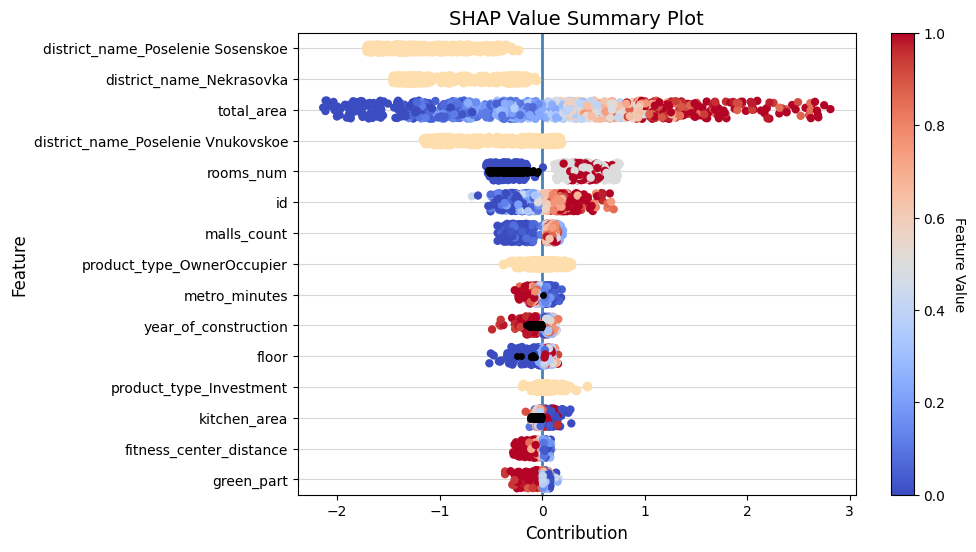

In [ ]:
my_beeswarm(shap_values, df[features], features)

Пример ниже. Не удаляйте пример!

CPU times: total: 1.61 s
Wall time: 1.61 s


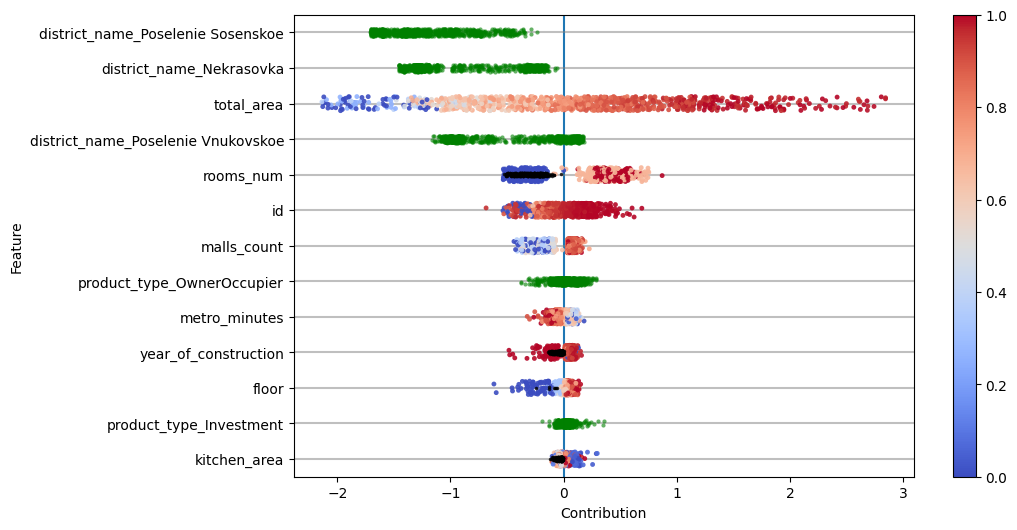

In [ ]:
%%time
from utils import shap_beeswarm

shap_beeswarm(model, df, features, cat_feature_threshold=0.001, shap_values=shap_values, top_k=13, figsize=(10, 6), dots=1000)

## 2. Логирование градиентов при обучении (4 балла)

**Задача:** хотим для каждого объекта для каждого дерева получить gi - производную лосса!
Чтобы:
- нарисовать карту объект-дерево
- поизучать 2D-представления
- призадуматься...

**Как:** придумайте способ! Нужно в процессе обучения сохранять градиенты LogLoss`а объектов на каждом дереве, после чего продемонстрировать собранные градиенты с помощью sns.clustermap.

Ниже пример. Не удаляйте пример!

In [2]:
class GradientCollector:
  """
    Класс для сбора градиентов на каждой итерации (для каждого дерева) в процессе обучения модели градиентного бустинга.

    Параметры:
    ----------
    true_labels : numpy.ndarray
        Истинные значения целевой переменной
    num_trees : int
        Количество деревьев в модели

    Атрибуты:
    ---------
    gradients : numpy.ndarray
        Матрица размером (num_trees, len(true_labels)) для хранения градиентов
        на каждой итерации обучения
    current_iter : int
        Текущая итерация (номер дерева) для которого сохраняется градиент
  """
    def __init__(self, true_labels, num_trees):
        self.true_labels = true_labels
        self.gradients = np.zeros((num_trees, len(true_labels)))
        self.current_iter = 0

    def __call__(self, env):
        y_pred = env.model.predict(env.model.train_set.data, raw_score=True)
        y_pred = 1.0 / (1.0 + np.exp(-y_pred))
        grads = y_pred - self.true_labels

        if self.current_iter < self.gradients.shape[0]:
            self.gradients[self.current_iter, :] = grads
            self.current_iter += 1

Пример. Не удаляйте пример!

In [3]:
def get_split(df, val_size=0.33):
    train_idx = np.random.choice(df.index, size=int(df.shape[0]*(1-val_size)), replace=False)
    val_idx = np.setdiff1d(df.index, train_idx)
    return df.loc[train_idx].reset_index(drop=True), df.loc[val_idx].reset_index(drop=True)

tr, val = get_split(df, val_size=0.23)
lgb_tr = lgb.Dataset(tr[features], tr.result_price_bin, free_raw_data=False)

In [4]:
collector = GradientCollector(true_labels=tr.result_price_bin.values, num_trees=100)

model = lgb.train(
    {'objective': 'binary', 'verbose': -1},
    lgb_tr,
    num_boost_round=100,
    callbacks=[collector]
)

/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1500x1500 with 0 Axes>

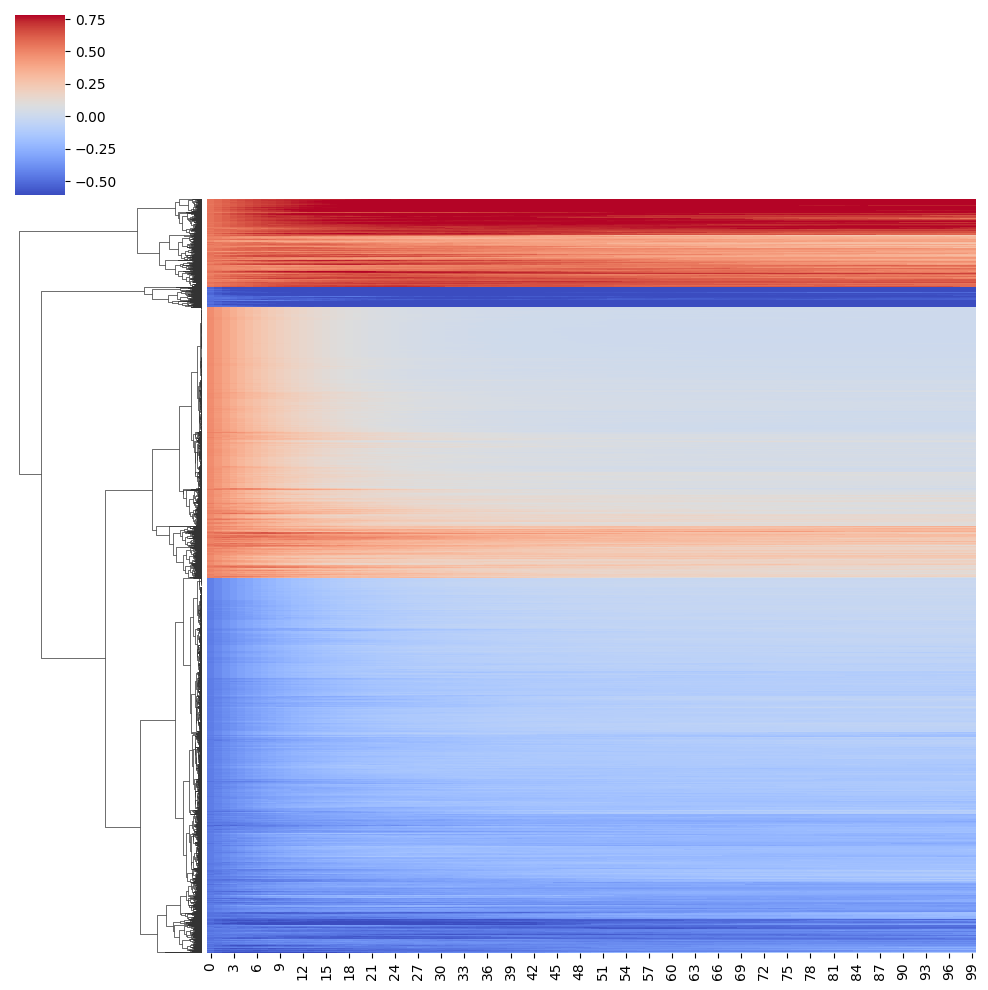

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 15))
sns.clustermap(collector.gradients.T, col_cluster=False, robust=True, yticklabels=False, cmap='coolwarm')
plt.show()

CPU times: total: 1min 17s
Wall time: 1min 17s


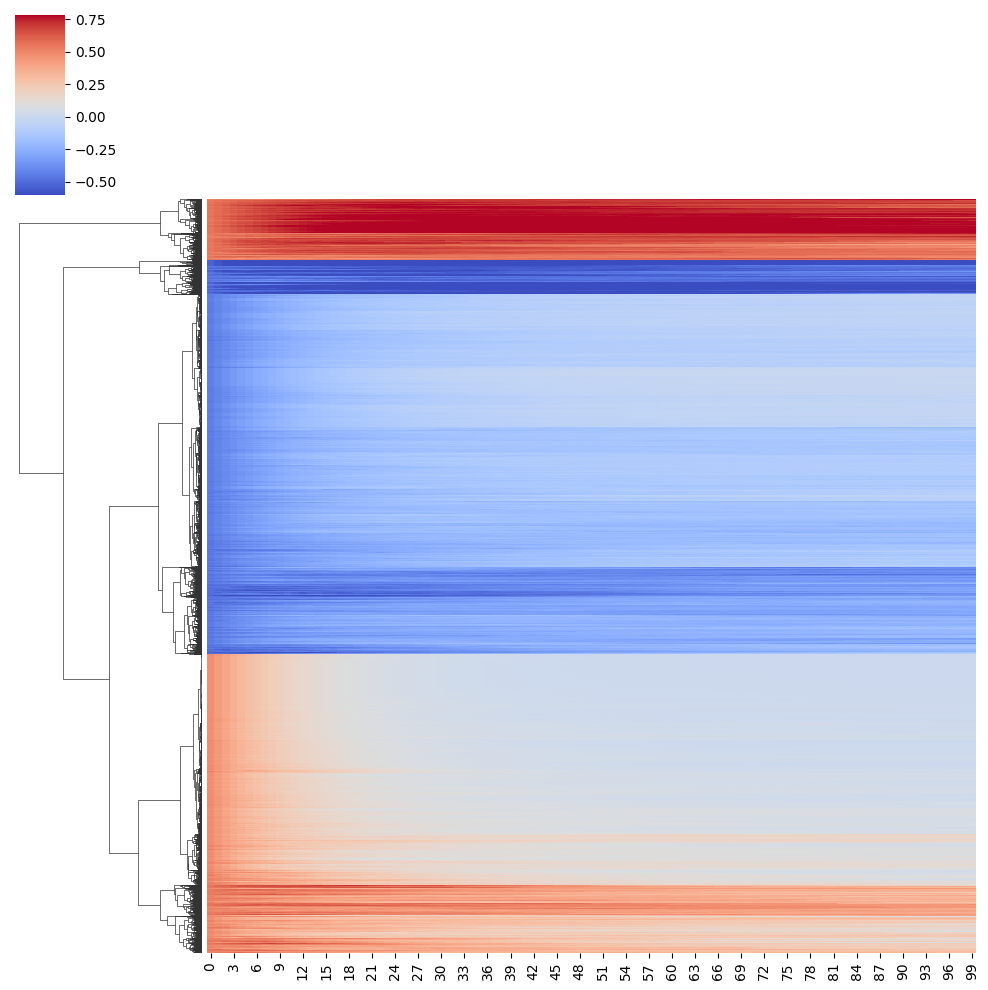

In [ ]:
%%time
import seaborn as sns

# предварительно установите fastcluster: pip install fastcluster, иначе считаться будет долго
sns.clustermap(grads.T, col_cluster=False, robust=True, yticklabels=False, cmap='coolwarm')

## 3. Автоматическое создание весов для бинарной классификации (5 баллов)

В этом блоке ваша цель - написать функцию, которая генерирует вектор весов для объектов обучающей выборки следующим образом:

1) на вход подается таргет-колонка и произвольная колонка

2) если колонка числовая, бьем ее на бины (кол-во бинов `bins` принимаем на вход. берем небольшое, около 7-13)

    - если в колонке < `bins` уникальных, бить не надо

3) если колонка категориальная, тоже бьем ее на бины

    - если уникальных значений <= `bins`, то за бины считаем уникальные значения категории
    - если уникальных значений >  `bins`, то выбираем `bins` - 1 самых популярных категорий у объектов класса 1
    - не попавшие в топ самых популярных категории запихиваем в бин 'other'

4) проходимся по всем бинам, присваивая всем объектам класса 1, попавшим в бин, вес n_0_in_bin / n_1_in_bin,
       если объектов класса 0, попавших в этот бин, достаточное кол-во (принимайте на вход, зависит от задачи)

5) всем объектам класса 0 присваиваем вес, равный единице

Такая схема на практике работает лучше, чем обычный `scale_pos_weight` параметр в LightGBM и его аналоги, если разумно выбирать
    вспомогательную колонку. Подумайте, как именно нужно выбирать такую колонку. Ответ писать не обязательно, но можно :)

**Обязательно:**
Найдите способ продемонстрировать визуализацией, что ваша функция работает корректно!

In [27]:
from pandas.api.types import is_numeric_dtype

def calculate_weights(target_col, feature_col, bins=10, min_n0_in_bin=10):
  """
    Вычисляет веса для наблюдений класса 1 на основе соотношения классов в бинах/категориях фичи.

    Для каждого бина/категории вычисляется соотношение n0/n1 (количество наблюдений класса 0
    к количеству наблюдений класса 1), которое используется как вес для наблюдений класса 1
    в этом бине. Наблюдения класса 0 всегда имеют вес 1.0.

    Параметры:
    ----------
    target_col : pd.Series
        Столбец с целевой переменной (бинарной: 0 и 1)
    feature_col : pd.Series
        Столбец с фичей, по которой будет производиться бинирование/группировка
    bins : int, optional
        Количество бинов/групп для числовых фич или максимальное количество категорий
        для категориальных фич (по умолчанию 10)
    min_n0_in_bin : int, optional
        Минимальное количество наблюдений класса 0 в бине для расчета весов
        (по умолчанию 10). Если в бине меньше наблюдений класса 0, веса для
        этого бина не рассчитываются.

    Возвращает:
    -----------
    pd.Series
        Серия с весами для каждого наблюдения (1.0 для класса 0, n0/n1 для класса 1)
  """
  weights = pd.Series(1.0, index=target_col.index)
  class1_mask = (target_col == 1)

  if pd.api.types.is_datetime64_any_dtype(feature_col):
    pass
  elif is_numeric_dtype(feature_col):
    if feature_col.nunique() < bins:
      bins = feature_col.nunique()
    else:
      if bins > 1:
            try:
                binned = pd.qcut(feature_col, q=bins, duplicates='drop')
                actual_bins = len(binned.cat.categories)
                if actual_bins < 2:
                    return weights
            except ValueError:
                binned = pd.cut(feature_col, bins=bins, duplicates='drop')
  else:
      unique_values = feature_col.nunique()

      if unique_values <= bins:
          binned = feature_col.astype('category')
      else:
          top_categories = (feature_col[class1_mask].value_counts().nlargest(bins - 1)
                            .index)
          binned = np.where(feature_col.isin(top_categories), feature_col, 'other')
          binned = pd.Series(binned, index=feature_col.index).astype('category')

  for bin_name in binned.cat.categories if hasattr(binned, 'cat') else pd.unique(binned):
        in_bin_mask = (binned == bin_name)
        class0_in_bin = in_bin_mask & (target_col == 0)
        class1_in_bin = in_bin_mask & (target_col == 1)

        n0 = class0_in_bin.sum()
        n1 = class1_in_bin.sum()

        if n0 >= min_n0_in_bin and n1 > 0:
            weights.loc[class1_in_bin] = n0 / n1

  return weights

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_numeric_feature_distribution(target_col, feature_col, weights=None, bins=100):
    """
    Визуализирует распределение числовой фичи по классам целевой переменной.

    Параметры:
    ----------
    target_col : pd.Series
        Столбец с целевой переменной
    feature_col : pd.Series
        Столбец с числовой фичей, распределение которой нужно визуализировать
    weights : pd.Series, optional
        Столбец с весами наблюдений (по умолчанию None - веса не используются)
    bins : int, optional
        Количество бинов для гистограммы (по умолчанию 100)

    """
    plt.figure(figsize=(6, 3))

    if weights is None:
        sns.histplot(
            data=pd.DataFrame({'feature': feature_col, 'target': target_col}),
            x='feature',
            hue='target',
            bins=bins,
            multiple='stack',
            palette={0: 'blue', 1: 'red'},
            alpha=0.7
        )
        plt.title("Распределение фичи по классам (без весов)")

    else:
        weighted_data = pd.DataFrame({
            'feature': feature_col,
            'target': target_col,
            'weights': weights
        })

        sns.histplot(
            data=weighted_data[weighted_data['target'] == 0],
            x='feature',
            color='blue',
            bins=bins,
            alpha=0.7,
            label='Class 0 (n0)'
        )

        sns.histplot(
            data=weighted_data[weighted_data['target'] == 1],
            x='feature',
            weights='weights',
            color='red',
            bins=bins,
            alpha=0.7,
            label='Class 1 (n1 * weight)'
        )
        plt.title("Распределение фичи по классам (с весами)")

    plt.xlim(0, 150)
    plt.xlabel(feature_col.name)
    plt.ylabel("Количество наблюдений")
    plt.show()

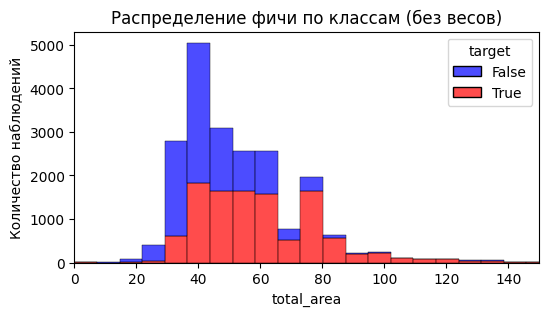

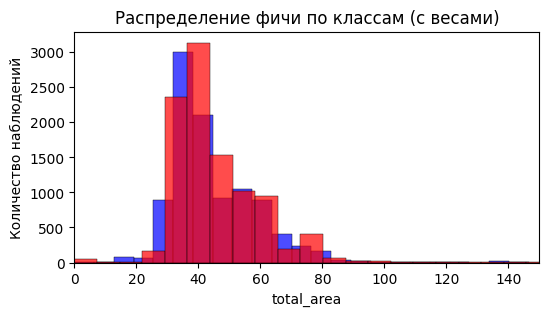

In [33]:
weights = calculate_weights(tr.result_price_bin, tr.total_area)
plot_numeric_feature_distribution(tr.result_price_bin, tr.total_area)  # До взвешивания
plot_numeric_feature_distribution(tr.result_price_bin, tr.total_area, weights=weights)  # После взвешивания

In [51]:
def plot_categorical_feature_distribution(target_col, feature_col, weights=None, top_categories=10):
    """
    Визуализация распределения категориальной фичи по классам
    с возможностью учета весов.

    Параметры:
        target_col: pd.Series - бинарная целевая переменная (0 и 1)
        feature_col: pd.Series - категориальная фича
        weights: pd.Series - веса наблюдений (None для невзвешенного варианта)
        top_categories: int - количество отображаемых категорий
    """
    plt.figure(figsize=(12, 6))
    df_plot = pd.DataFrame({
        'feature': feature_col,
        'target': target_col.astype(int)
    })

    if weights is None:
        count_data = df_plot.groupby(['feature', 'target']).size().unstack().fillna(0)

        count_data = count_data.sort_values(1, ascending=False).head(top_categories)

        count_data.plot(kind='bar',
                        color=['blue', 'red'], alpha=0.7,
                        title="Распределение категорий по классам (без весов)")

    else:
        df_plot['weights'] = weights

        class0 = df_plot[df_plot['target'] == 0].groupby('feature')['weights'].count()
        class1 = df_plot[df_plot['target'] == 1].groupby('feature')['weights'].sum()


        count_data = pd.DataFrame({
            '0': class0,
            '1 (weighted)': class1
        }).fillna(0)

        count_data = count_data.sort_values('1 (weighted)', ascending=False).head(top_categories)

        count_data.plot(kind='bar', color=['blue', 'red'], alpha=0.7,
                        title="Распределение категорий по классам (с весами)")

    plt.xlabel("Категории продукта")
    plt.ylabel("Количество наблюдений")
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Класс')
    plt.tight_layout()
    plt.show()

<ipython-input-51-265cf11dcd4a>:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = df_plot.groupby(['feature', 'target']).size().unstack().fillna(0)


<Figure size 1200x600 with 0 Axes>

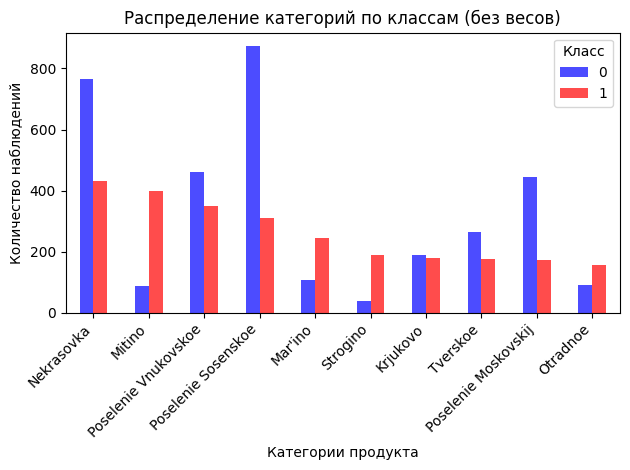

<ipython-input-51-265cf11dcd4a>:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  class0 = df_plot[df_plot['target'] == 0].groupby('feature')['weights'].count()
<ipython-input-51-265cf11dcd4a>:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  class1 = df_plot[df_plot['target'] == 1].groupby('feature')['weights'].sum()


<Figure size 1200x600 with 0 Axes>

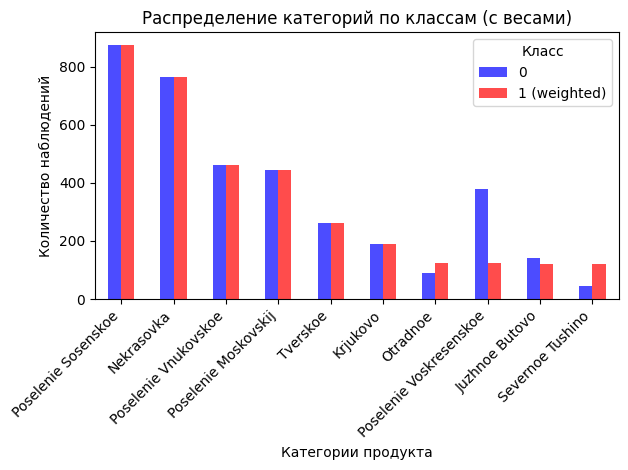

In [52]:
weights = calculate_weights(tr.result_price_bin, tr.district_name)
plot_categorical_feature_distribution(tr.result_price_bin, tr.district_name)  # До взвешивания
plot_categorical_feature_distribution(tr.result_price_bin, tr.district_name, weights=weights)  # После взвешивания